[*********************100%***********************]  1 of 1 completed

data download succesfully


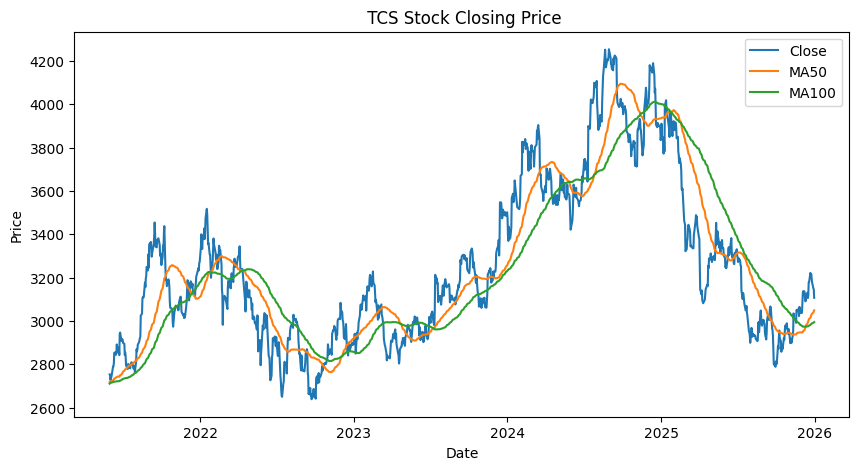

x_train shape: (849, 60, 4)
x_test shape: (168, 60, 4)
Epoch 1/20


c:\Users\asus\.vscode\stock_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0341 - val_loss: 0.0133
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0100 - val_loss: 0.0131
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0076 - val_loss: 0.0054
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0072 - val_loss: 0.0027
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0059 - val_loss: 0.0019
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0059 - val_loss: 0.0043
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0062 - val_loss: 0.0016
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0056 - val_loss: 0.0017
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0046 - val_loss: 0.0017
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0042 - val_loss: 0.0022
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0041 - val_loss: 0.0013
Epoch 12/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0041 - val_l

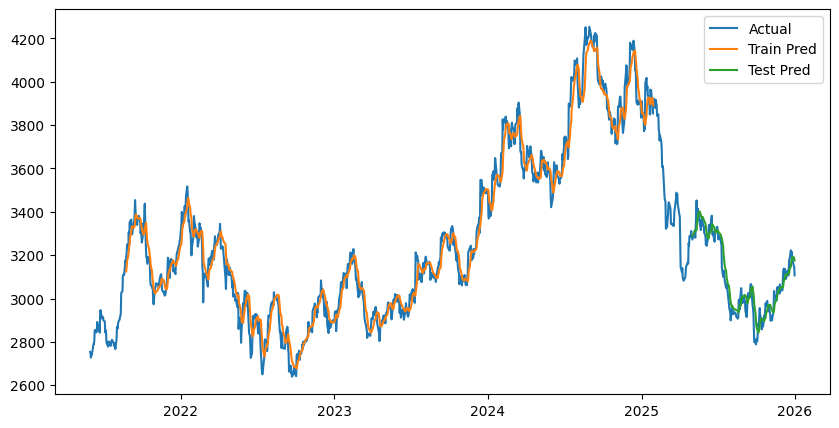

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
next Day Price - 3159.6994017195393
✅ Dashboard saved! Opening in browser...


In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'vscode'
df = yf.download("TCS.NS", start="2021-1-1" , end="2026-1-1")
df.columns = df.columns.get_level_values(0)
if df.empty:
     print("data download failed")
else:
    print("data download succesfully")    
df.head(10)
df.tail(10)
df.sample(10)
df['Close'] = df['Close'].astype(float)
df['MA50'] = df['Close'].rolling(50).mean()
df['MA100'] = df['Close'].rolling(100).mean()
df['Returns'] = df['Close'].pct_change()
df.dropna(inplace=True)


#df.isnull().sum()
#print(len(df))
#print(df.dtypes)

# plotting the data 
plt.figure(figsize =(10,5))
plt.plot(df['Close'],label = "Close")
plt.plot(df['MA50'],label = "MA50")
plt.plot(df['MA100'],label = "MA100")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.title(" TCS Stock Closing Price")
plt.show()


# data preprocessing 
from sklearn.preprocessing import MinMaxScaler

data = df[[ 'Close','MA50','MA100','Returns']]

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)


# train test split
train_size = int(len(scaled_data)*0.8)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# creating dataset
def create_dataset(data,time_step=60):
    x, y = [], []
    for i in range(time_step,len(data)):
        x.append(data[i-time_step:i])
        y.append(data[i,0])
    return np.array(x),np.array(y)
    
x_train, y_train = create_dataset(train_data)
x_test , y_test = create_dataset(test_data)

#reshaping data for lstm
x_train = x_train.reshape(x_train.shape[0],x_train.shape[1],x_train.shape[2])
x_test = x_test.reshape(x_test.shape[0],x_test.shape[1],x_test.shape[2])

print("x_train shape:",x_train.shape)
print("x_test shape:",x_test.shape)

# build model 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Dropout

model = Sequential()

model.add(LSTM(50, return_sequences = True, input_shape =(x_train.shape[1], x_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(loss = 'mean_squared_error', optimizer= 'adam')
# train model 
history = model.fit(x_train,y_train,epochs = 20, batch_size = 32, validation_data =(x_test , y_test))
print(history.history['loss'])
model.save("model.keras")
import pickle
pickle.dump(scaler,open("scaler.pkl","wb"))

# prediction of the model
train_pred = model.predict(x_train)
test_pred = model.predict(x_test) 

# ab yha inverse transform krege kyuki 4 cloumn h ab
def inverse_transform(pred,scaler):
     temp = np.zeros((len(pred),4))
     temp[:,0] = pred.flatten()
     temp = scaler.inverse_transform(temp)
     return temp[:,0]
train_pred = inverse_transform(train_pred, scaler)
test_pred = inverse_transform(test_pred, scaler)

#root mean square error
from sklearn.metrics import mean_squared_error
import numpy as np 

rmse = np.sqrt(mean_squared_error(y_test,test_pred))
print("RMSE : ",rmse)

# plotiing the results 

import numpy as np

time_step = 60

train_plot = np.empty(len(df))
train_plot[:] = np.nan

test_plot = np.empty(len(df))
test_plot[:] = np.nan


train_plot[time_step:len(train_pred)+time_step] = train_pred.flatten()


test_start = train_size + time_step
test_plot[test_start:test_start + len(test_pred)] = test_pred.flatten()

# final plot
plt.figure(figsize=(10,5))
plt.plot(df.index , df['Close'], label="Actual")
plt.plot(df.index,train_plot, label="Train Pred")
plt.plot(df.index , test_plot, label="Test Pred")

plt.legend()
plt.show()

time_step = 60

last_60 = scaled_data[-60:]
last_60 = last_60.reshape(1,60,4)

next_price = model.predict(last_60)
temp = np.zeros((1,4))
temp[0,0] = next_price[0][0]
next_price = scaler.inverse_transform(temp)
print("next Day Price -",next_price[0][0])
# --- Plotly Figure (Dark Theme) ---
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df.index,
    y=df['Close'].values,
    mode='lines',
    name='Actual',
    line=dict(color='#94a3b8', width=1.5)
))

fig.add_trace(go.Scatter(
    x=df.index[time_step : time_step + len(train_pred)],
    y=train_pred,
    mode='lines',
    name='Train Pred',
    line=dict(color='#2dd4bf', width=2)
))

fig.add_trace(go.Scatter(
    x=df.index[train_size + time_step : train_size + time_step + len(test_pred)],
    y=test_pred,
    mode='lines',
    name='Test Pred',
    line=dict(color='#f59e0b', width=2)
))

fig.update_layout(
    paper_bgcolor='#0f172a',
    plot_bgcolor='#0f172a',
    font=dict(color='#94a3b8', family='monospace'),
    title=None,
    xaxis=dict(
        gridcolor='#1e293b',
        zerolinecolor='#1e293b',
        tickfont=dict(color='#64748b', size=11),
        showspikes=True,
        spikecolor='#334155',
        spikethickness=1
    ),
    yaxis=dict(
        gridcolor='#1e293b',
        zerolinecolor='#1e293b',
        tickfont=dict(color='#64748b', size=11),
        tickprefix='₹',
        showspikes=True,
        spikecolor='#334155',
        spikethickness=1
    ),
    legend=dict(
        bgcolor='#1e293b',
        bordercolor='#334155',
        borderwidth=1,
        font=dict(color='#94a3b8', size=12)
    ),
    hovermode='x unified',
    hoverlabel=dict(
        bgcolor='#1e293b',
        bordercolor='#334155',
        font=dict(color='#e2e8f0', size=12)
    ),
    margin=dict(l=60, r=30, t=20, b=60),
)

fig.update_traces(
    hovertemplate='₹%{y:,.2f}<extra></extra>'
)

# --- Metrics Calculate karo ---
current_price = float(df['Close'].iloc[-1])
predicted_next = next_price[0][0]
price_change = predicted_next - current_price
change_pct = (price_change / current_price) * 100
high_52w = float(df['Close'].tail(252).max())
low_52w = float(df['Close'].tail(252).min())
avg_vol = float(df['Returns'].std() * 100)

arrow = '▲' if price_change >= 0 else '▼'
change_color = '#10b981' if price_change >= 0 else '#ef4444'

# --- Chart HTML inject karo ---
chart_html = fig.to_html(full_html=False, include_plotlyjs='cdn', config={
    'displayModeBar': True,
    'modeBarButtonsToRemove': ['lasso2d', 'select2d'],
    'displaylogo': False
})

# --- Full Dashboard HTML ---
html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>TCS Stock — Prediction Dashboard</title>
<link href="https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@300;400;500;600&family=Syne:wght@400;600;700&display=swap" rel="stylesheet">
<style>
  *, *::before, *::after {{ box-sizing: border-box; margin: 0; padding: 0; }}

  body {{
    background: #070d1a;
    color: #94a3b8;
    font-family: 'JetBrains Mono', monospace;
    min-height: 100vh;
    padding: 0;
  }}

  /* Top bar */
  .topbar {{
    background: #0a1628;
    border-bottom: 1px solid #1e293b;
    padding: 0 2rem;
    height: 52px;
    display: flex;
    align-items: center;
    justify-content: space-between;
    position: sticky;
    top: 0;
    z-index: 100;
  }}
  .topbar-left {{
    display: flex;
    align-items: center;
    gap: 1.5rem;
  }}
  .ticker {{
    font-family: 'Syne', sans-serif;
    font-size: 1.1rem;
    font-weight: 700;
    color: #e2e8f0;
    letter-spacing: 0.05em;
  }}
  .badge {{
    background: #0f2d4a;
    color: #38bdf8;
    font-size: 0.65rem;
    padding: 2px 8px;
    border-radius: 3px;
    border: 1px solid #0ea5e9;
    letter-spacing: 0.08em;
  }}
  .live-dot {{
    width: 7px;
    height: 7px;
    background: #10b981;
    border-radius: 50%;
    animation: pulse 2s infinite;
    display: inline-block;
    margin-right: 6px;
  }}
  @keyframes pulse {{
    0%, 100% {{ opacity: 1; }}
    50% {{ opacity: 0.3; }}
  }}
  .topbar-right {{
    font-size: 0.7rem;
    color: #475569;
    letter-spacing: 0.05em;
  }}

  /* Main layout */
  .main {{
    max-width: 1400px;
    margin: 0 auto;
    padding: 1.5rem 2rem 3rem;
  }}

  /* Section title */
  .section-label {{
    font-size: 0.65rem;
    letter-spacing: 0.15em;
    color: #475569;
    text-transform: uppercase;
    margin-bottom: 0.75rem;
  }}

  /* Metric cards */
  .metrics {{
    display: grid;
    grid-template-columns: repeat(5, 1fr);
    gap: 1px;
    background: #1e293b;
    border: 1px solid #1e293b;
    border-radius: 8px;
    overflow: hidden;
    margin-bottom: 1.5rem;
  }}
  .metric {{
    background: #0a1628;
    padding: 1.1rem 1.25rem;
    display: flex;
    flex-direction: column;
    gap: 0.35rem;
  }}
  .metric-label {{
    font-size: 0.62rem;
    letter-spacing: 0.12em;
    color: #475569;
    text-transform: uppercase;
  }}
  .metric-value {{
    font-size: 1.25rem;
    font-weight: 600;
    color: #e2e8f0;
    letter-spacing: -0.01em;
  }}
  .metric-sub {{
    font-size: 0.7rem;
    color: #475569;
  }}
  .metric-value.up {{ color: #10b981; }}
  .metric-value.down {{ color: #ef4444; }}

  /* Prediction highlight card */
  .pred-highlight {{
    background: #0a1628;
    border: 1px solid #1e3a5f;
    border-left: 3px solid #2dd4bf;
    border-radius: 8px;
    padding: 1.1rem 1.5rem;
    margin-bottom: 1.5rem;
    display: flex;
    align-items: center;
    justify-content: space-between;
  }}
  .pred-label {{
    font-size: 0.65rem;
    letter-spacing: 0.15em;
    color: #2dd4bf;
    text-transform: uppercase;
    margin-bottom: 0.3rem;
  }}
  .pred-price {{
    font-family: 'Syne', sans-serif;
    font-size: 2rem;
    font-weight: 700;
    color: #e2e8f0;
    letter-spacing: -0.02em;
  }}
  .pred-change {{
    font-size: 0.85rem;
    font-weight: 500;
    margin-top: 0.2rem;
  }}
  .pred-right {{
    text-align: right;
  }}
  .model-tag {{
    background: #0f2d4a;
    border: 1px solid #1e4a7a;
    color: #7dd3fc;
    font-size: 0.62rem;
    padding: 4px 10px;
    border-radius: 3px;
    letter-spacing: 0.1em;
    margin-bottom: 0.4rem;
    display: inline-block;
  }}
  .rmse-val {{
    font-size: 0.8rem;
    color: #475569;
  }}
  .rmse-val span {{
    color: #94a3b8;
    font-weight: 500;
  }}

  /* Chart wrapper */
  .chart-wrap {{
    background: #0f172a;
    border: 1px solid #1e293b;
    border-radius: 8px;
    overflow: hidden;
    margin-bottom: 1.5rem;
  }}
  .chart-header {{
    padding: 0.8rem 1.25rem;
    border-bottom: 1px solid #1e293b;
    display: flex;
    align-items: center;
    justify-content: space-between;
  }}
  .chart-title {{
    font-size: 0.7rem;
    letter-spacing: 0.1em;
    color: #64748b;
    text-transform: uppercase;
  }}
  .legend-pills {{
    display: flex;
    gap: 1rem;
    align-items: center;
  }}
  .legend-item {{
    display: flex;
    align-items: center;
    gap: 6px;
    font-size: 0.65rem;
    color: #64748b;
  }}
  .legend-dot {{
    width: 20px;
    height: 2px;
    border-radius: 1px;
  }}

  /* Footer */
  .footer {{
    text-align: center;
    font-size: 0.62rem;
    color: #1e293b;
    margin-top: 2rem;
    letter-spacing: 0.08em;
  }}

  /* Scan line animation on body */
#   body::after {{
#     content: '';
#     position: fixed;
#     top: 0; left: 0;
#     width: 100%;
#     height: 2px;
#     background: linear-gradient(90deg, transparent, #2dd4bf22, transparent);
#     animation: scan 4s linear infinite;
#     pointer-events: none;
#   }}
  @keyframes scan {{
    0% {{ top: 0; }}
    100% {{ top: 100vh; }}
  }}
</style>
</head>
<body>

<div class="topbar">
  <div class="topbar-left">
    <span class="ticker">TCS.NS</span>
    <span class="badge">NSE · NIFTY50</span>
    <span style="font-size:0.7rem; color:#64748b;">
      <span class="live-dot"></span>LSTM Prediction Model
    </span>
  </div>
  <div class="topbar-right">
    DATA: 2021 – 2026 &nbsp;|&nbsp; EPOCHS: 20 &nbsp;|&nbsp; LOOKBACK: 60D
  </div>
</div>

<div class="main">

  <!-- Prediction Highlight -->
  <div class="pred-highlight">
    <div>
      <div class="pred-label">Next day predicted price</div>
      <div class="pred-price">₹{predicted_next:,.2f}</div>
      <div class="pred-change" style="color:{change_color}">
        {arrow} ₹{abs(price_change):,.2f} &nbsp;({change_pct:+.2f}%) vs today
      </div>
    </div>
    <div class="pred-right">
      <div class="model-tag">LSTM · 2-LAYER · DROPOUT 0.2</div>
      <div class="rmse-val">RMSE &nbsp;<span>{rmse:.4f}</span></div>
    </div>
  </div>

  <!-- Metric Cards -->
  <div class="metrics">
    <div class="metric">
      <div class="metric-label">Current Price</div>
      <div class="metric-value">₹{current_price:,.0f}</div>
      <div class="metric-sub">Last close</div>
    </div>
    <div class="metric">
      <div class="metric-label">52W High</div>
      <div class="metric-value up">₹{high_52w:,.0f}</div>
      <div class="metric-sub">Trailing 252 days</div>
    </div>
    <div class="metric">
      <div class="metric-label">52W Low</div>
      <div class="metric-value down">₹{low_52w:,.0f}</div>
      <div class="metric-sub">Trailing 252 days</div>
    </div>
    <div class="metric">
      <div class="metric-label">Avg Volatility</div>
      <div class="metric-value">±{avg_vol:.2f}%</div>
      <div class="metric-sub">Daily returns std</div>
    </div>
    <div class="metric">
      <div class="metric-label">Training Split</div>
      <div class="metric-value">80/20</div>
      <div class="metric-sub">Train / Test ratio</div>
    </div>
  </div>

  <!-- Chart -->
  <div class="chart-wrap">
    <div class="chart-header">
      <span class="chart-title">Price Chart · Actual vs Predicted</span>
      <div class="legend-pills">
        <div class="legend-item">
          <div class="legend-dot" style="background:#94a3b8"></div> Actual
        </div>
        <div class="legend-item">
          <div class="legend-dot" style="background:#2dd4bf"></div> Train Pred
        </div>
        <div class="legend-item">
          <div class="legend-dot" style="background:#f59e0b"></div> Test Pred
        </div>
      </div>
    </div>
    {chart_html}
  </div>

  <div class="footer">
    GENERATED BY LSTM MODEL &nbsp;·&nbsp; TATA CONSULTANCY SERVICES &nbsp;·&nbsp; NSE INDIA
  </div>

</div>
</body>
</html>"""

with open("stock_prediction.html", "w", encoding="utf-8") as f:
    f.write(html)

import webbrowser, os
webbrowser.open("file://" + os.path.abspath("stock_prediction.html"))
print("✅ Dashboard saved! Opening in browser...")
